# lab1. Препроцессинг датасета "Грибы"
Описание метода: предварительная обработка данных включает в себя чистку: удаление дубликатов, исключение выбросов, использование тепловой матрицы для удаления сильно зависимых признаков, а также выбор наиболее важных для настройки модели признаков посредством алгоритма Gain Ratio (коэффициент усиления) из алгоритма классификации с помощью деревьев решений C4.5

## 1. Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor as SKMLPReg, MLPClassifier as SKMLP

## 2. Загрузка и просмотр данных

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/mushroom/dataset.csv', sep=';')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df.head())

print('--- Типы данных и наличие значений ---')
print(df.info())
print('\n--- Базовая статистика числовых признаков ---')
display(df.describe())

# Проверка баланса классов
print("Распределение целевой переменной:")
print(df['ядовитый'].value_counts(normalize=True))

Размер датасета: 8124 строк, 23 столбцов

--- Первые 5 строк ---


,ядовитый,кепкообразная форма,поверхность крышки,цвет крышки,синяки,запах,прикрепление пластинок,расстояние между пластинами,размер пластин,цвет пластин,...,поверхность стебля под кольцом,Цвет стебля над кольцом,Цвет стебля под кольцом,вуаль типа,цвет вуали,номер звонка,кольцевой,цвет-отпечатка споры,Население,естественная среда
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ядовитый                        8124 non-null   object
 1   кепкообразная форма             8124 non-null   object
 2   поверхность крышки              8124 non-null   object
 3   цвет крышки                     8124 non-null   object
 4   синяки                          8124 non-null   object
 5   запах                           8124 non-null   object
 6   прикрепление пластинок          8124 non-null   object
 7   расстояние между пластинами     8124 non-null   object
 8   размер пластин                  8124 non-null   object
 9   цвет пластин                    8124 non-null   object
 10  стебельчатая форма              8124 non-null   object
 11  стебель-корень                  8124 non-null   object
 12  поверхнос

,ядовитый,кепкообразная форма,поверхность крышки,цвет крышки,синяки,запах,прикрепление пластинок,расстояние между пластинами,размер пластин,цвет пластин,...,поверхность стебля под кольцом,Цвет стебля над кольцом,Цвет стебля под кольцом,вуаль типа,цвет вуали,номер звонка,кольцевой,цвет-отпечатка споры,Население,естественная среда
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Распределение целевой переменной:
ядовитый
e    0.517971
p    0.482029
Name: proportion, dtype: float64


## 3. Очистка и восстановление данных

In [ ]:
print(f'Размер до очистки: {df.shape}')

# 1. Заменяем '?' на NaN во всём датасете
df = df.replace('?', np.nan)

# 2. Считаем пропуски до удаления
print(f'Пропусков до очистки: {df.isnull().sum().sum()}')

# 3. Удаляем строки с любыми пропусками
df_clean = df.dropna().reset_index(drop=True)

# 4. Проверяем результат
print(f'Размер после очистки: {df_clean.shape}')
print(f'Удалено строк: {len(df) - len(df_clean)}')

# Проверка на дубликаты
print(f"Дубликатов: {df_clean.duplicated().sum()}")

# 5. Удаление дубликатов
df_clean = df_clean.drop_duplicates()

print(f'Всего удалено {len(df) - len(df_clean)} строк')

Размер до очистки: (8124, 23)
Пропусков до очистки: 2480
Размер после очистки: (5644, 23)
Удалено строк: 2480
Дубликатов: 0
Всего удалено 2480 строк


## 4. Кодирование категориальных признаков

In [ ]:
# Создаём копию для безопасности
df_encoded = df_clean.copy()

# Сохранить маппинг для интерпретации
mappings = {}

# LabelEncoder для всех столбцов
for column in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_clean[column])
    mappings[column] = dict(zip(le.classes_, range(len(le.classes_))))


# Проверка результата. Все должны быть int64
print(df_encoded.dtypes)

ядовитый                          int64
кепкообразная форма               int64
поверхность крышки                int64
цвет крышки                       int64
синяки                            int64
запах                             int64
прикрепление пластинок            int64
расстояние между пластинами       int64
размер пластин                    int64
цвет пластин                      int64
стебельчатая форма                int64
стебель-корень                    int64
поверхность стебля над кольцом    int64
поверхность стебля под кольцом    int64
Цвет стебля над кольцом           int64
Цвет стебля под кольцом           int64
вуаль типа                        int64
цвет вуали                        int64
номер звонка                      int64
кольцевой                         int64
цвет-отпечатка споры              int64
Население                         int64
естественная среда                int64
dtype: object


## 5. Оценка баланса классов

In [ ]:
# Проверка баланса классов
print("Распределение целевой переменной:")
print(df_clean['ядовитый'].value_counts(normalize=True))

Распределение целевой переменной:
ядовитый
e    0.618001
p    0.381999
Name: proportion, dtype: float64


## 6. Анализ корреляций и тепловая матрица

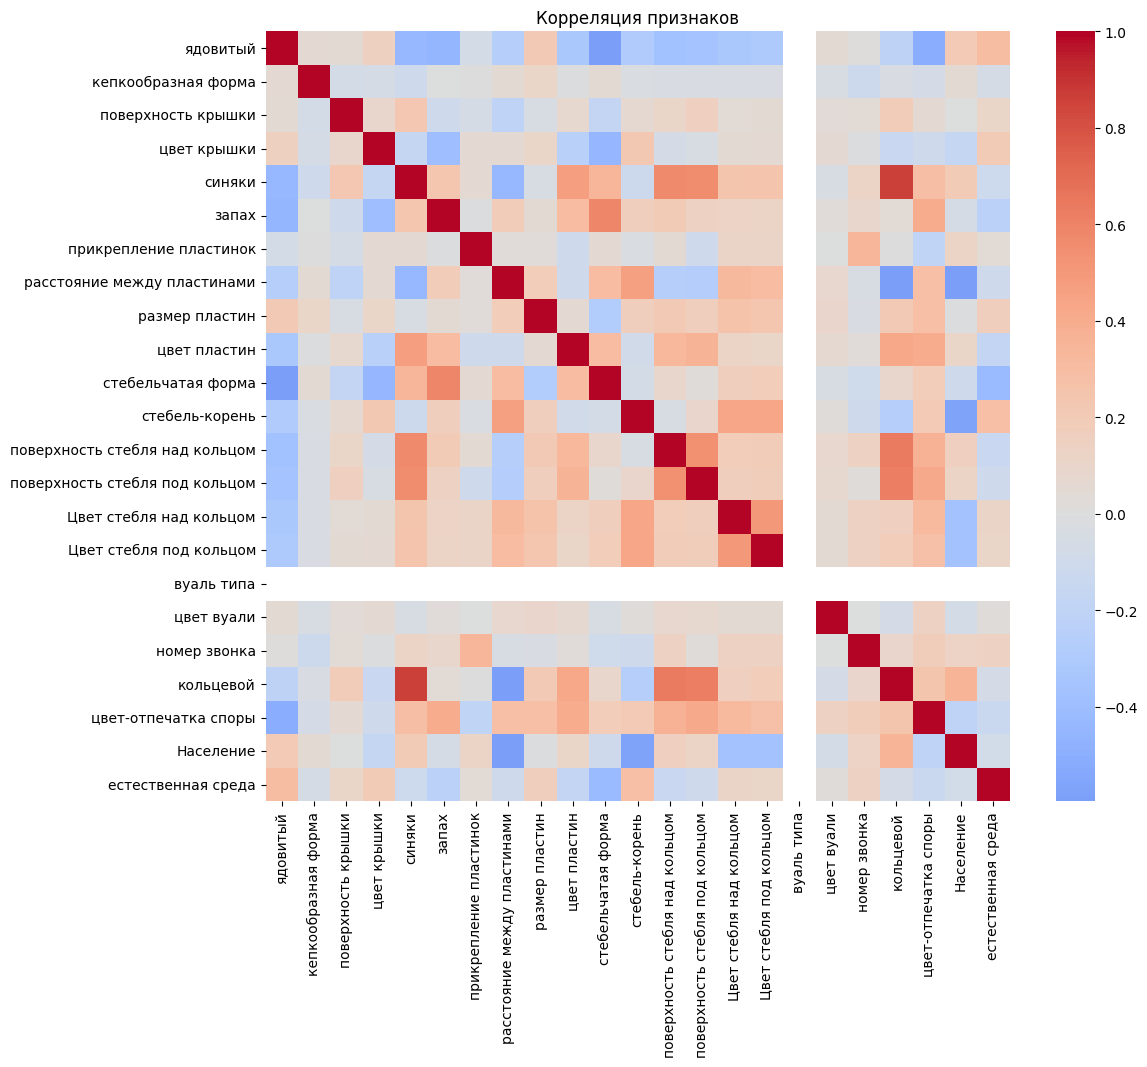

Всего признаков: 22
Оставлено (|r| >= 0.1): 16
Удалено (|r| < 0.1): 5

--- Удалённые признаки (слабая корреляция) ---
прикрепление пластинок   -0.071945
кепкообразная форма       0.053155
цвет вуали                0.047921
поверхность крышки        0.046859
номер звонка              0.008615
Name: ядовитый, dtype: float64

--- Оставленные признаки (важные) ---
стебельчатая форма               -0.592446
цвет-отпечатка споры             -0.507034
запах                            -0.455566
синяки                           -0.435562
поверхность стебля над кольцом   -0.375910
поверхность стебля под кольцом   -0.363604
цвет пластин                     -0.318339
Цвет стебля над кольцом          -0.317244
Цвет стебля под кольцом          -0.308613
естественная среда                0.297412
стебель-корень                   -0.291026
расстояние между пластинами      -0.264160
размер пластин                    0.215289
кольцевой                        -0.215200
Население                         0

In [ ]:

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title('Корреляция признаков')
plt.show()


# 1. Вычисляем корреляцию каждого признака с целевой переменной
target = 'ядовитый'
correlations = df_encoded.corr()[target].drop(target)  # исключаем корреляцию с самим собой

# 2. Задаём порог
threshold = 0.1
strong_corr = correlations[abs(correlations) >= threshold]
weak_corr = correlations[abs(correlations) < threshold]

# 3. Выводим статистику
print(f"Всего признаков: {len(correlations)}")
print(f"Оставлено (|r| >= {threshold}): {len(strong_corr)}")
print(f"Удалено (|r| < {threshold}): {len(weak_corr)}")

print("\n--- Удалённые признаки (слабая корреляция) ---")
print(weak_corr.sort_values(key=abs, ascending=False))

print("\n--- Оставленные признаки (важные) ---")
print(strong_corr.sort_values(key=abs, ascending=False))

# 4. Формируем новый датасет
features_to_keep = strong_corr.index.tolist() + [target]
df_filtered = df_encoded[features_to_keep].copy()

print(f"\nРазмер после отбора: {df_filtered.shape}")

## 7. Расчёт Gain Ratio (алгоритм C4.5)


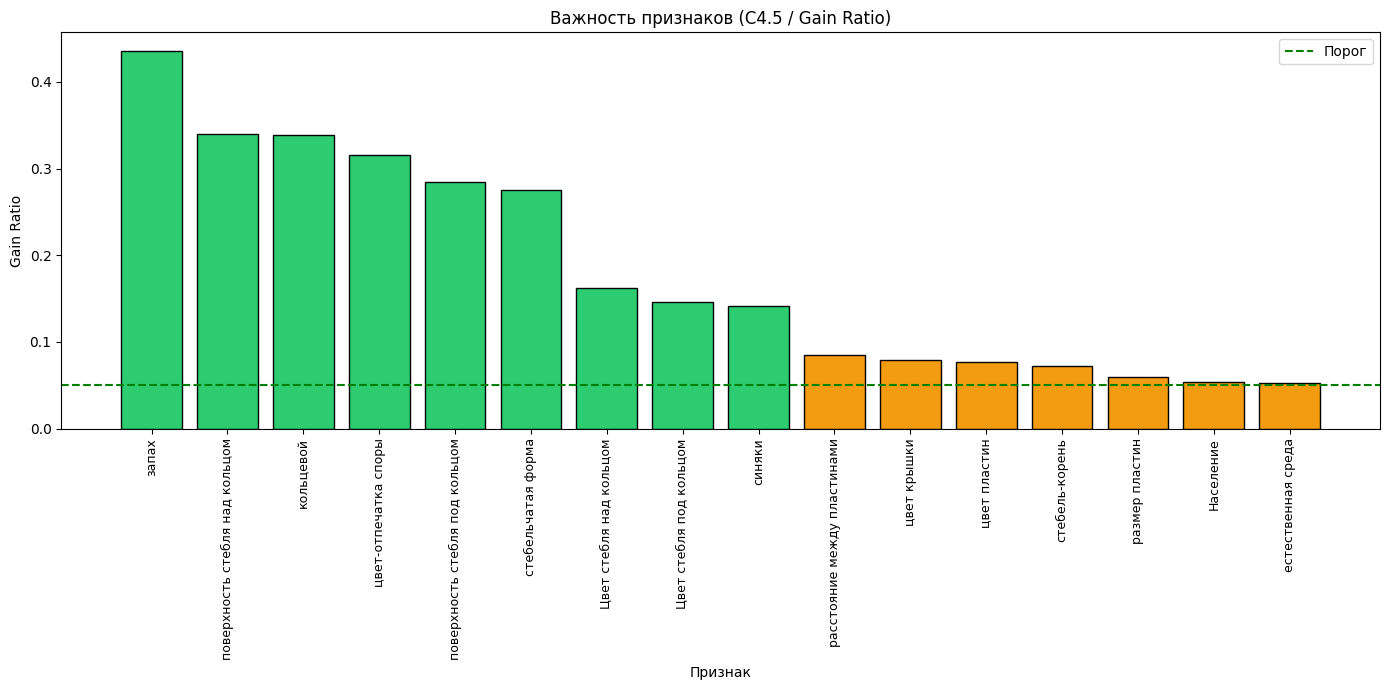

In [ ]:
# === Вспомогательные функции ===
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(X_col, y):
    total_entropy = entropy(y)
    values, counts = np.unique(X_col.dropna(), return_counts=True)
    weighted_entropy = sum(
        (c / len(X_col)) * entropy(y[X_col == v])
        for v, c in zip(values, counts)
    )
    return total_entropy - weighted_entropy

def split_info(X_col):
    values, counts = np.unique(X_col.dropna(), return_counts=True)
    probs = counts / len(X_col)
    return -np.sum(probs * np.log2(probs + 1e-12))

def gain_ratio(X_col, y):
    ig = information_gain(X_col, y)
    si = split_info(X_col)
    return 0 if si == 0 else ig / si

# === Расчёт важности признаков ===
X = df_filtered.drop('ядовитый', axis=1)
y = df_filtered['ядовитый']

gain_ratios = {col: gain_ratio(X[col], y) for col in X.columns}
feature_importance = pd.DataFrame({
    'признак': list(gain_ratios.keys()),
    'gain_ratio': list(gain_ratios.values())
}).sort_values('gain_ratio', ascending=False).reset_index(drop=True)

# Визуализация
plt.figure(figsize=(14, 7))
colors = ['#2ecc71' if gr >= 0.1 else '#f39c12' if gr >= 0.05 else '#e74c3c'
          for gr in feature_importance['gain_ratio']]
plt.bar(range(len(feature_importance)), feature_importance['gain_ratio'],
        color=colors, edgecolor='black')
plt.axhline(y=0.05, color='green', linestyle='--', label='Порог')
plt.xticks(range(len(feature_importance)), feature_importance['признак'],
           rotation=90, fontsize=9)
plt.xlabel('Признак'); plt.ylabel('Gain Ratio')
plt.title('Важность признаков (C4.5 / Gain Ratio)')
plt.legend(); plt.tight_layout(); plt.show()

# Отбор топ 10 признаков
selected_features = feature_importance.head(10)['признак'].tolist()
df_final = df_filtered[selected_features + ['ядовитый']].copy()

## 8. Подготовка данных и обучение модели

In [ ]:

# Разделяем признаки и целевую переменную
X = df_final[selected_features]  # selected_features из предыдущего шага
y = df_final['ядовитый']

# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} примеров')
print(f'Тестовая выборка: {X_test.shape[0]} примеров')
print(f'\nРаспределение классов в train: {y_train.value_counts().to_dict()}')
print(f'Распределение классов в test: {y_test.value_counts().to_dict()}')

# Обучаем модель
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

Обучающая выборка: 4515 примеров
Тестовая выборка: 1129 примеров

Распределение классов в train: {0: 2790, 1: 1725}
Распределение классов в test: {0: 698, 1: 431}


DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

## 9. Оценка модели, матрица ошибок

Точность на тесте: 0.9903
              precision    recall  f1-score   support

   Съедобный       1.00      0.99      0.99       698
    Ядовитый       0.98      0.99      0.99       431

    accuracy                           0.99      1129
   macro avg       0.99      0.99      0.99      1129
weighted avg       0.99      0.99      0.99      1129



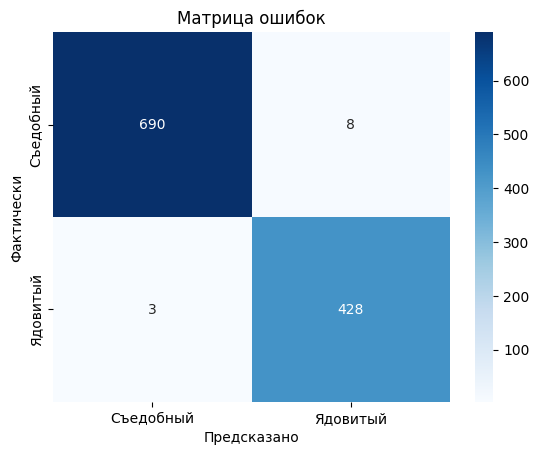

In [ ]:
# Прогнозы и метрики
y_test_pred = model.predict(X_test)
print(f"Точность на тесте: {accuracy_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred,
                           target_names=['Съедобный', 'Ядовитый']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Съедобный', 'Ядовитый'],
            yticklabels=['Съедобный', 'Ядовитый'])
plt.xlabel('Предсказано'); plt.ylabel('Фактически')
plt.title('Матрица ошибок'); plt.show()

## 10. Важность признаков

In [ ]:
# Важность признаков в обученной модели
importance_df = pd.DataFrame({
    'признак': selected_features,
    'важность': model.feature_importances_
}).sort_values('важность', ascending=False)
print(importance_df.to_string(index=False))


                       признак  важность
          цвет-отпечатка споры  0.631916
            стебельчатая форма  0.181083
                         запах  0.144051
                        синяки  0.042950
поверхность стебля над кольцом  0.000000
                     кольцевой  0.000000
поверхность стебля под кольцом  0.000000
       Цвет стебля над кольцом  0.000000
       Цвет стебля под кольцом  0.000000
   расстояние между пластинами  0.000000


## 11. Дерево решений

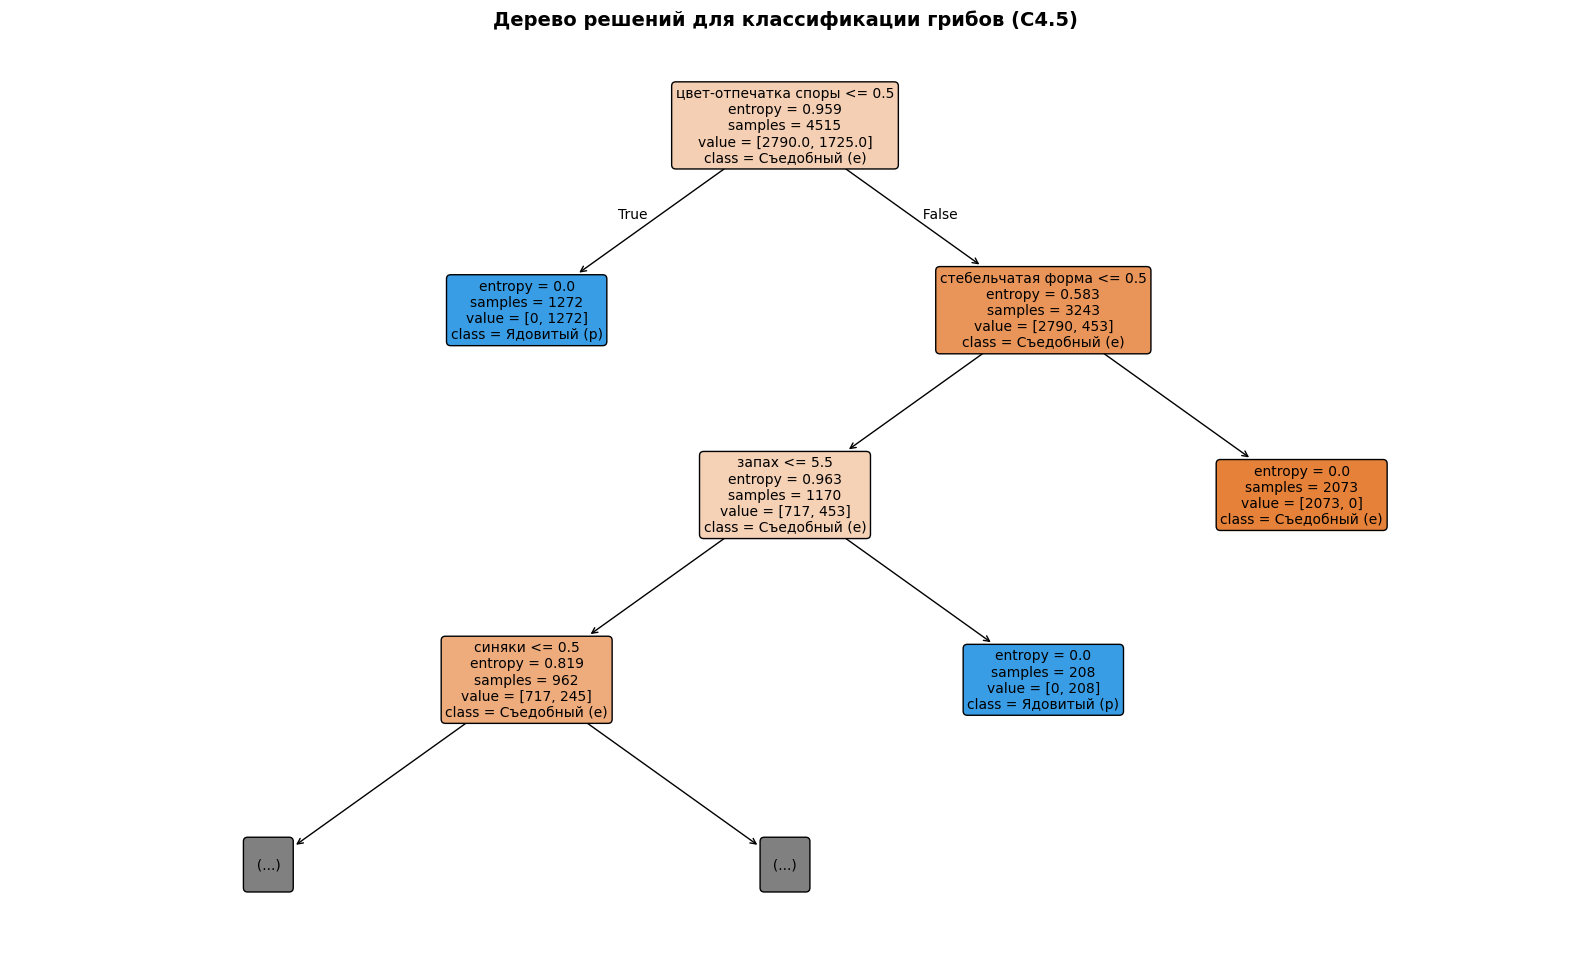

In [ ]:
# Настройка фигуры
plt.figure(figsize=(20, 12))

# Рисуем дерево
plot_tree(
    model,
    feature_names=selected_features,
    class_names=['Съедобный (e)', 'Ядовитый (p)'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3            # Показываем первые 3 уровня
)

plt.title('Дерево решений для классификации грибов (C4.5)', fontsize=14, fontweight='bold')
plt.show()